In [1]:

# Since web search is unavailable, I'll attempt to compute the Davenport-Heilbronn zeros
# from first principles using the mathematical definition provided

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.special import zeta
import os

# Create downloads directory
os.makedirs('downloads', exist_ok=True)

# Define the Davenport-Heilbronn L-function
# L_DH(s) = ((1-i*kappa)/2) * L(s, chi) + ((1+i*kappa)/2) * L(s, chi_bar)
# where chi is the non-principal character mod 4
# and kappa ≈ 0.28408

kappa = 0.28408

# The non-principal character mod 4 is chi(n) = 0 if n even, +1 if n ≡ 1 (mod 4), -1 if n ≡ 3 (mod 4)
def chi_4(n):
 """Non-principal character mod 4"""
 if n % 2 == 0:
 return 0
 elif n % 4 == 1:
 return 1
 else: # n % 4 == 3
 return -1

# Compute L(s, chi_4) using Dirichlet series
def L_chi4(s, N_terms=5000):
 """
 Compute L(s, chi_4) = sum_{n=1}^∞ chi(n) / n^s
 """
 result = 0
 for n in range(1, N_terms):
 chi_n = chi_4(n)
 if chi_n != 0:
 result += chi_n / (n ** s)
 return result

# Davenport-Heilbronn coefficients
def a_DH(n):
 """Davenport-Heilbronn coefficient"""
 chi_n = chi_4(n)
 return ((1 - 1j*kappa)/2) * chi_n + ((1 + 1j*kappa)/2) * np.conj(chi_n)

# Davenport-Heilbronn L-function
def L_DH(s, N_terms=5000):
 """
 L_DH(s) = sum_{n=1}^∞ a_DH(n) / n^s
 """
 result = 0
 for n in range(1, N_terms):
 coeff = a_DH(n)
 if coeff != 0:
 result += coeff / (n ** s)
 return result

# Test at a point
s_test = 2 + 0j
print(f"Testing L_DH at s = {s_test}:")
print(f"L_DH({s_test}) = {L_DH(s_test)}")
print(f"|L_DH({s_test})| = {abs(L_DH(s_test))}")


Testing L_DH at s = (2+0j):
L_DH((2+0j)) = (0.91596557417722+0j)
|L_DH((2+0j))| = 0.91596557417722


In [2]:

# Let me search for zeros in the critical strip
# We'll create a grid search for zeros with 0 < Re(s) < 1 but Re(s) ≠ 1/2

def L_DH_real_imag(s_real, s_imag, N_terms=5000):
 """Return real and imaginary parts of L_DH as separate values"""
 s = s_real + 1j * s_imag
 L_val = L_DH(s, N_terms)
 return np.array([L_val.real, L_val.imag])

# Grid search for zeros
# Focus on regions away from Re(s) = 0.5
sigma_values = []
t_values = []
modulus_values = []

print("Searching for zeros in critical strip (this may take a moment)...")

# Search in strips: 0.1 < Re(s) < 0.4 and 0.6 < Re(s) < 0.9
for sigma in np.linspace(0.1, 0.9, 50):
 if abs(sigma - 0.5) < 0.05: # Skip near critical line
 continue
 for t in np.linspace(0, 30, 300):
 s = sigma + 1j * t
 L_val = L_DH(s, N_terms=3000)
 mod = abs(L_val)
 
 if mod < 0.5: # Potential zero nearby
 sigma_values.append(sigma)
 t_values.append(t)
 modulus_values.append(mod)

# Sort by modulus to find candidates
sorted_indices = np.argsort(modulus_values)
print("\nTop 20 candidates for zeros (smallest |L_DH(s)|):")
print("Re(s)\t\tIm(s)\t\t|L_DH(s)|")
for i in range(min(20, len(sorted_indices))):
 idx = sorted_indices[i]
 print(f"{sigma_values[idx]:.6f}\t{t_values[idx]:.6f}\t{modulus_values[idx]:.8f}")


Searching for zeros in critical strip (this may take a moment)...



Top 20 candidates for zeros (smallest |L_DH(s)|):
Re(s)		Im(s)		|L_DH(s)|
0.442857	6.020067	0.07431421
0.557143	6.020067	0.07434582
0.573469	6.020067	0.09358277
0.557143	10.234114	0.09392531
0.426531	6.020067	0.09695828
0.589796	6.020067	0.11246836
0.557143	16.354515	0.11285025
0.410204	6.020067	0.12011450
0.573469	10.234114	0.12050749
0.442857	10.234114	0.12493242
0.557143	23.277592	0.12778394
0.606122	6.020067	0.13098767
0.557143	28.394649	0.13124655
0.442857	16.354515	0.13176357
0.557143	18.260870	0.13747743
0.557143	6.120401	0.14038813
0.557143	21.471572	0.14178283
0.573469	16.354515	0.14221287
0.393878	6.020067	0.14376166
0.442857	23.277592	0.14420988


In [3]:

# Refine the top candidates using numerical optimization
from scipy.optimize import fsolve, minimize

def L_DH_for_root_finding(s_array):
 """Wrapper for root finding - returns [Re(L), Im(L)]"""
 s = s_array[0] + 1j * s_array[1]
 L_val = L_DH(s, N_terms=8000)
 return [L_val.real, L_val.imag]

# Refine top candidates
refined_zeros = []

print("Refining candidate zeros...")
# Start with diverse initial guesses
initial_guesses = [
 [0.442857, 6.020067],
 [0.557143, 6.020067],
 [0.573469, 6.020067],
 [0.426531, 6.020067],
 [0.410204, 6.020067],
 [0.442857, 10.234114],
 [0.557143, 10.234114],
 [0.573469, 10.234114],
]

for guess in initial_guesses:
 try:
 solution = fsolve(L_DH_for_root_finding, guess, full_output=True)
 s_refined = solution[0]
 info = solution[1]
 
 # Check if it's actually a zero
 L_check = L_DH(s_refined[0] + 1j*s_refined[1], N_terms=8000)
 mod_check = abs(L_check)
 
 if mod_check < 0.01: # Good zero
 # Check if already in list (avoid duplicates)
 is_duplicate = False
 for existing in refined_zeros:
 if abs(existing[0] - s_refined[0]) < 0.01 and abs(existing[1] - s_refined[1]) < 0.1:
 is_duplicate = True
 break
 
 if not is_duplicate:
 refined_zeros.append([s_refined[0], s_refined[1], mod_check])
 print(f"Found: σ={s_refined[0]:.8f}, t={s_refined[1]:.8f}, |L|={mod_check:.2e}")
 except:
 pass

print(f"\nTotal refined zeros found: {len(refined_zeros)}")


Refining candidate zeros...
Found: σ=0.49719160, t=6.02429528, |L|=1.21e-15


Found: σ=0.49783706, t=10.24604389, |L|=1.46e-13



Total refined zeros found: 2


In [4]:

# These are on the critical line! Let me search more systematically for OFF-line zeros
# I need to expand the search region and look more carefully

print("Searching for OFF-line zeros (Re(s) ≠ 0.5) in critical strip...")

sigma_values = []
t_values = []
modulus_values = []

# Search more thoroughly, especially away from critical line
for sigma in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
 print(f"Scanning σ = {sigma}...")
 for t in np.linspace(0.5, 40, 800):
 s = sigma + 1j * t
 L_val = L_DH(s, N_terms=5000)
 mod = abs(L_val)
 
 if mod < 0.3: # Potential zero or near-zero
 sigma_values.append(sigma)
 t_values.append(t)
 modulus_values.append(mod)

# Sort by modulus
sorted_indices = np.argsort(modulus_values)
print("\nTop 30 candidates for OFF-line zeros:")
print("Re(s)\t\tIm(s)\t\t|L_DH(s)|")
for i in range(min(30, len(sorted_indices))):
 idx = sorted_indices[i]
 if abs(sigma_values[idx] - 0.5) > 0.01: # Only show off-line
 print(f"{sigma_values[idx]:.6f}\t{t_values[idx]:.6f}\t{modulus_values[idx]:.8f}")


Searching for OFF-line zeros (Re(s) ≠ 0.5) in critical strip...
Scanning σ = 0.2...


Scanning σ = 0.25...


Scanning σ = 0.3...


Scanning σ = 0.35...


Scanning σ = 0.4...


...

Scanning σ = 0.65...


Scanning σ = 0.7...


Scanning σ = 0.75...


Scanning σ = 0.8...



Top 30 candidates for OFF-line zeros:
Re(s)		Im(s)		|L_DH(s)|
0.550000	6.036921	0.06681614
0.550000	5.987484	0.07148882
0.450000	6.036921	0.07779008
0.450000	5.987484	0.08272207
0.550000	10.239049	0.08456398
0.450000	10.239049	0.10313043
0.550000	18.297247	0.10438772
0.550000	16.319775	0.10537524
0.550000	13.007509	0.10893386
0.550000	6.086358	0.10895223
0.550000	16.369212	0.11093416
0.550000	10.288486	0.11121638
0.450000	13.007509	0.11196219
0.550000	21.461202	0.11331344
0.550000	28.382353	0.11567892
0.550000	29.667710	0.11626531
0.550000	5.938048	0.11740550
0.550000	23.290363	0.11749164
0.550000	28.332916	0.11763550
0.450000	6.086358	0.12046352
0.550000	12.958073	0.12130162
0.450000	23.290363	0.12186169
0.600000	6.036921	0.12391045
0.450000	28.382353	0.12489790
0.600000	5.987484	0.12617176
0.450000	12.958073	0.12646086
0.450000	28.332916	0.12706091
0.450000	29.667710	0.12857247
0.450000	18.297247	0.12892753
0.550000	34.215895	0.12894671


In [5]:

# Now refine these candidates more carefully
# It appears the zeros might be very close to the critical line but not exactly on it

refined_off_line = []

# Test candidates at σ = 0.45 and σ = 0.55 (slightly off critical line)
test_guesses = [
 [0.45, 6.036921],
 [0.55, 6.036921],
 [0.45, 5.987484],
 [0.55, 5.987484],
 [0.45, 10.239049],
 [0.55, 10.239049],
 [0.45, 13.007509],
 [0.55, 13.007509],
 [0.45, 16.319775],
 [0.55, 16.319775],
 [0.45, 18.297247],
 [0.55, 18.297247],
 [0.6, 6.036921],
 [0.4, 6.036921],
 [0.6, 10.239049],
 [0.4, 10.239049],
]

print("Refining OFF-line candidate zeros with higher precision...")
for guess in test_guesses:
 try:
 solution = fsolve(L_DH_for_root_finding, guess, full_output=True, xtol=1e-10)
 s_refined = solution[0]
 
 # Check with high precision
 L_check = L_DH(s_refined[0] + 1j*s_refined[1], N_terms=10000)
 mod_check = abs(L_check)
 
 if mod_check < 0.001 and abs(s_refined[0] - 0.5) > 0.001: # Off-line zero
 # Check for duplicates
 is_duplicate = False
 for existing in refined_off_line:
 if abs(existing[0] - s_refined[0]) < 0.001 and abs(existing[1] - s_refined[1]) < 0.05:
 is_duplicate = True
 break
 
 if not is_duplicate:
 refined_off_line.append([s_refined[0], s_refined[1], mod_check])
 print(f"OFF-LINE: σ={s_refined[0]:.10f}, t={s_refined[1]:.10f}, |L|={mod_check:.2e}")
 except:
 pass

print(f"\nTotal OFF-line zeros found: {len(refined_off_line)}")


Refining OFF-line candidate zeros with higher precision...



Total OFF-line zeros found: 0


In [6]:

# The issue is that my numerical search is converging to the critical line.
# Let me reconsider: perhaps I need to use the proper Davenport-Heilbronn function definition.
# 
# The classical Davenport-Heilbronn zeros are known from the literature.
# Let me check if there's a relation to the functional equation or if I need
# to use a different formulation.

# Actually, the Davenport-Heilbronn function is more complex - it involves
# linear combinations of L-functions. Let me verify the formula more carefully.

# For the non-principal character mod 5 (not mod 4!), there are known exceptional zeros.
# Let me reconsider the problem statement.

# The user mentions κ ≈ 0.28408 - this is a specific value.
# Let me search the mathematical literature computationally by testing
# if there are any papers or known results about this.

# Since I cannot access web search, let me try a different approach:
# Search for zeros using a parameter sweep of κ

print("Testing if there are documented κ values with off-line zeros...")
print("κ ≈ 0.28408 was specified")
print()

# Let me try the definition more carefully with proper normalization
# Perhaps the issue is with how I'm computing the Dirichlet L-function

# Actually, for character mod 4, we have the functional equation relating
# L(s, chi) to L(1-s, chi_bar)

# Let me try computing with explicit functional equation
def dirichlet_beta(s, N_terms=5000):
 """
 Dirichlet beta function: β(s) = sum_{n=0}^∞ (-1)^n / (2n+1)^s
 This is L(s, chi_4) where chi_4 is the non-principal character mod 4
 """
 result = 0
 for n in range(N_terms):
 result += (-1)**n / (2*n + 1)**s
 return result

# Test
s_test = 2 + 0j
beta_val = dirichlet_beta(s_test)
print(f"Dirichlet β(2) = {beta_val}")
print(f"Known value ≈ 0.915965594... (Catalan's constant)")
print()

# Now compute L_DH using beta
def L_DH_v2(s, kappa=0.28408, N_terms=5000):
 """
 Alternative formulation using Dirichlet beta
 """
 beta_s = dirichlet_beta(s, N_terms)
 beta_s_conj = np.conj(beta_s) # For the conjugate character
 
 L_DH = ((1 - 1j*kappa)/2) * beta_s + ((1 + 1j*kappa)/2) * beta_s_conj
 return L_DH

# Test
L_test = L_DH_v2(2 + 0j)
print(f"L_DH(2) = {L_test}")
print(f"|L_DH(2)| = {abs(L_test)}")


Testing if there are documented κ values with off-line zeros...
κ ≈ 0.28408 was specified

Dirichlet β(2) = (0.9159655891772144+0j)
Known value ≈ 0.915965594... (Catalan's constant)

L_DH(2) = (0.9159655891772144+0j)
|L_DH(2)| = 0.9159655891772144


In [7]:

# The issue is that for real s, beta(s) is real, so the imaginary part cancels
# Let me try with complex s values in the critical strip

# First, let me search more systematically for off-line zeros
# using a finer grid and looking at both sides of the critical line

print("Systematic search for off-line zeros...")
print("Using L_DH with κ = 0.28408")
print()

kappa_val = 0.28408

# Create a detailed map
candidate_zeros = []

for sigma in np.linspace(0.3, 0.7, 41):
 if abs(sigma - 0.5) < 0.02: # Skip very close to critical line
 continue
 
 for t in np.linspace(1, 25, 241):
 s = sigma + 1j * t
 L_val = L_DH_v2(s, kappa=kappa_val, N_terms=6000)
 mod = abs(L_val)
 
 if mod < 0.15:
 candidate_zeros.append({'sigma': sigma, 't': t, 'modulus': mod})

# Sort and display
candidate_zeros.sort(key=lambda x: x['modulus'])

print("Top 30 candidates:")
print("σ\t\tt\t\t|L_DH(σ+it)|")
for i, cand in enumerate(candidate_zeros[:30]):
 print(f"{cand['sigma']:.6f}\t{cand['t']:.6f}\t{cand['modulus']:.8f}")


Systematic search for off-line zeros...
Using L_DH with κ = 0.28408



Top 30 candidates:
σ		t		|L_DH(σ+it)|
0.470000	5.700000	0.00009338
0.320000	5.400000	0.00013892
0.480000	18.500000	0.00014160
0.430000	5.600000	0.00028978
0.310000	18.000000	0.00040560
0.470000	12.800000	0.00071390
0.590000	16.100000	0.00077397
0.400000	6.300000	0.00092857
0.480000	13.100000	0.00094187
0.380000	5.500000	0.00113677
0.460000	9.700000	0.00187350
0.450000	6.200000	0.00206947
0.420000	12.700000	0.00268185
0.570000	16.200000	0.00296511
0.540000	21.400000	0.00319743
0.520000	10.200000	0.00362895
0.300000	16.500000	0.00371140
0.580000	21.300000	0.00383769
0.360000	23.000000	0.00394231
0.450000	23.100000	0.00408553
0.350000	23.600000	0.00421943
0.450000	21.500000	0.00455431
0.330000	6.400000	0.00512314
0.550000	21.000000	0.00522986
0.390000	10.400000	0.00571873
0.550000	10.100000	0.00595076
0.530000	16.300000	0.00598928
0.560000	15.900000	0.00601277
0.340000	12.600000	0.00620509
0.470000	10.300000	0.00661689


In [8]:

# Excellent! Now let me refine these candidates to high precision
# Focus on the best candidates that are clearly off the critical line

from scipy.optimize import fsolve

def L_DH_root_v2(s_array, kappa=0.28408):
 """Wrapper for root finding"""
 s = s_array[0] + 1j * s_array[1]
 L_val = L_DH_v2(s, kappa=kappa, N_terms=10000)
 return [L_val.real, L_val.imag]

# Select diverse candidates that are clearly off-line
initial_guesses = [
 [0.47, 5.7], # Strong candidate
 [0.32, 5.4], # Strong candidate, further from critical line
 [0.48, 18.5], # Another strong candidate
 [0.43, 5.6], # Good candidate
 [0.31, 18.0], # Good candidate
 [0.47, 12.8], # Moderate candidate
 [0.59, 16.1], # On the other side
 [0.4, 6.3], # Moderate
]

refined_zeros_final = []

print("Refining OFF-line zeros to high precision...")
print()

for guess in initial_guesses:
 try:
 # Use fsolve with tight tolerance
 solution = fsolve(lambda s: L_DH_root_v2(s, kappa=kappa_val), 
 guess, 
 full_output=True,
 xtol=1e-12,
 maxfev=10000)
 s_refined = solution[0]
 info = solution[1]
 
 # Verify with high-precision evaluation
 s_complex = s_refined[0] + 1j * s_refined[1]
 L_check = L_DH_v2(s_complex, kappa=kappa_val, N_terms=15000)
 mod_check = abs(L_check)
 
 # Only accept if it's a true zero and off the critical line
 if mod_check < 1e-6 and abs(s_refined[0] - 0.5) > 0.005:
 # Check for duplicates
 is_duplicate = False
 for existing in refined_zeros_final:
 if abs(existing[0] - s_refined[0]) < 0.001 and abs(existing[1] - s_refined[1]) < 0.05:
 is_duplicate = True
 break
 
 if not is_duplicate:
 refined_zeros_final.append([s_refined[0], s_refined[1], mod_check])
 print(f"Zero found: ρ = {s_refined[0]:.10f} + {s_refined[1]:.10f}i")
 print(f" |L_DH(ρ)| = {mod_check:.2e}")
 print(f" Distance from critical line: |σ - 0.5| = {abs(s_refined[0] - 0.5):.6f}")
 print()
 except Exception as e:
 pass

print(f"Total OFF-line zeros found: {len(refined_zeros_final)}")


Refining OFF-line zeros to high precision...



Total OFF-line zeros found: 0


In [9]:

# The solver is converging but not finding zeros with |L| < 1e-6
# Let me check what the solver is actually finding

print("Debugging: checking what fsolve is finding...")
print()

for i, guess in enumerate([[0.47, 5.7], [0.32, 5.4], [0.48, 18.5]]):
 print(f"Initial guess {i+1}: σ = {guess[0]}, t = {guess[1]}")
 
 # Evaluate at initial guess
 s_init = guess[0] + 1j * guess[1]
 L_init = L_DH_v2(s_init, kappa=kappa_val, N_terms=10000)
 print(f" L_DH(initial) = {L_init}")
 print(f" |L_DH(initial)| = {abs(L_init):.8f}")
 
 # Try to refine
 try:
 solution = fsolve(lambda s: L_DH_root_v2(s, kappa=kappa_val), 
 guess,
 full_output=True,
 xtol=1e-10)
 s_refined = solution[0]
 fvec = solution[1]['fvec']
 
 s_final = s_refined[0] + 1j * s_refined[1]
 L_final = L_DH_v2(s_final, kappa=kappa_val, N_terms=15000)
 
 print(f" Refined to: σ = {s_refined[0]:.10f}, t = {s_refined[1]:.10f}")
 print(f" L_DH(refined) = {L_final}")
 print(f" |L_DH(refined)| = {abs(L_final):.10f}")
 print(f" fvec = {fvec}")
 print()
 except Exception as e:
 print(f" Error: {e}")
 print()


Debugging: checking what fsolve is finding...

Initial guess 1: σ = 0.47, t = 5.7
 L_DH(initial) = (-0.010735586577429387+0j)
 |L_DH(initial)| = 0.01073559
 Refined to: σ = 0.4783179747, t = 5.7000000000
 L_DH(refined) = (0.007465649875878083+0j)
 |L_DH(refined)| = 0.0074656499
 fvec = [-4.85722573e-16 0.00000000e+00]

Initial guess 2: σ = 0.32, t = 5.4
 L_DH(initial) = (0.03954569695703558+0j)
 |L_DH(initial)| = 0.03954570
 Refined to: σ = 0.2741281809, t = 5.4000000000
 L_DH(refined) = (-0.05770550815649264+0j)
 |L_DH(refined)| = 0.0577055082
 fvec = [-3.55271368e-15 0.00000000e+00]

Initial guess 3: σ = 0.48, t = 18.5
 L_DH(initial) = (-0.003217506603008874+0j)
 |L_DH(initial)| = 0.00321751
 Refined to: σ = 0.4812209553, t = 18.5000000000
 L_DH(refined) = (0.004184595431129534+0j)
 |L_DH(refined)| = 0.0041845954
 fvec = [1.08246745e-15 0.00000000e+00]



In [10]:

# I see the issue - the imaginary part is already zero (the function is real for these points!)
# This means these aren't actually zeros, just points where Im(L) = 0
# But Re(L) ≠ 0

# The key insight: the Davenport-Heilbronn function for real character becomes real-valued
# for certain s values. Let me reconsider the problem.

# Actually, looking back at the user's definition:
# a_n^(DH) = ((1−iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)
# 
# For character mod 4: χ(n) = 0, ±1 (real values)
# So χ̄(n) = χ(n) for real characters!

# This means: a_n^(DH) = ((1−iκ)/2)·χ(n) + ((1+iκ)/2)·χ(n) = χ(n)

# Wait, that can't be right. Let me recalculate

chi_test = chi_4(5) # = 1 since 5 ≡ 1 mod 4
chi_bar_test = np.conj(chi_test) # = 1 since chi is real

a_test = ((1 - 1j*kappa_val)/2) * chi_test + ((1 + 1j*kappa_val)/2) * chi_bar_test
print(f"For n=5: χ(5) = {chi_test}")
print(f"a_DH(5) = {a_test}")
print()

# So a_DH(n) = χ(n) when χ is real-valued
# This means L_DH(s) = L(s, χ) for the real character mod 4

# But the problem says there are 4 known off-line zeros!
# Perhaps there's a different formulation or a different character.

# Let me check: maybe the character is mod 5 (which has complex values)?
print("Testing with character mod 5 instead...")

def chi_5(n):
 """Non-principal character mod 5 - there are two, let's use one"""
 # For mod 5, we can have chi(n) = exp(2πi k/4) for n ≡ k mod 5
 # The character mod 5: chi(2) = i, chi(3) = -i, chi(4) = -1, chi(1) = 1
 n_mod = n % 5
 if n_mod == 0:
 return 0
 elif n_mod == 1:
 return 1
 elif n_mod == 2:
 return 1j
 elif n_mod == 3:
 return -1j
 else: # n_mod == 4
 return -1

# Test
for n in range(1, 11):
 print(f"χ_5({n}) = {chi_5(n)}")


For n=5: χ(5) = 1
a_DH(5) = (1+0j)

Testing with character mod 5 instead...
χ_5(1) = 1
χ_5(2) = 1j
χ_5(3) = (-0-1j)
χ_5(4) = -1
χ_5(5) = 0
χ_5(6) = 1
χ_5(7) = 1j
χ_5(8) = (-0-1j)
χ_5(9) = -1
χ_5(10) = 0


In [11]:

# Now let me compute L_DH with character mod 5
def L_chi5(s, N_terms=5000):
 """L-function for character mod 5"""
 result = 0
 for n in range(1, N_terms):
 chi_n = chi_5(n)
 if chi_n != 0:
 result += chi_n / (n ** s)
 return result

def L_DH_mod5(s, kappa=0.28408, N_terms=5000):
 """
 Davenport-Heilbronn with character mod 5
 L_DH(s) = ((1-iκ)/2) L(s,χ) + ((1+iκ)/2) L(s,χ̄)
 """
 L_chi = L_chi5(s, N_terms)
 L_chi_bar = np.conj(L_chi5(np.conj(s), N_terms)) # L(s, χ̄)
 
 L_DH = ((1 - 1j*kappa)/2) * L_chi + ((1 + 1j*kappa)/2) * L_chi_bar
 return L_DH

# Test
s_test = 2 + 0j
L_test = L_DH_mod5(s_test, kappa=kappa_val)
print(f"L_DH_mod5(2) = {L_test}")
print(f"|L_DH_mod5(2)| = {abs(L_test)}")
print()

# Now search for zeros
print("Searching for zeros with character mod 5...")
candidates_mod5 = []

for sigma in np.linspace(0.25, 0.75, 51):
 if abs(sigma - 0.5) < 0.015:
 continue
 for t in np.linspace(0.5, 25, 246):
 s = sigma + 1j * t
 L_val = L_DH_mod5(s, kappa=kappa_val, N_terms=4000)
 mod = abs(L_val)
 
 if mod < 0.2:
 candidates_mod5.append({'sigma': sigma, 't': t, 'modulus': mod})

candidates_mod5.sort(key=lambda x: x['modulus'])

print("Top 20 candidates for mod 5:")
print("σ\t\tt\t\t|L_DH(σ+it)|")
for i, cand in enumerate(candidates_mod5[:20]):
 if abs(cand['sigma'] - 0.5) > 0.02:
 print(f"{cand['sigma']:.6f}\t{cand['t']:.6f}\t{cand['modulus']:.8f}")


L_DH_mod5(2) = (1.0000684507213582+0j)
|L_DH_mod5(2)| = 1.0000684507213582

Searching for zeros with character mod 5...


Top 20 candidates for mod 5:
σ		t		|L_DH(σ+it)|
0.520000	5.100000	0.02565027
0.480000	5.100000	0.02757659
0.520000	14.400000	0.03671861
0.530000	5.100000	0.03836915
0.470000	5.100000	0.04126767
0.540000	5.100000	0.05092826
0.460000	5.100000	0.05518572
0.480000	19.300000	0.05565096
0.530000	14.400000	0.05867633
0.480000	14.400000	0.05881013
0.550000	5.100000	0.06331689
0.450000	5.100000	0.06932271
0.520000	19.300000	0.07114810
0.560000	5.100000	0.07553357
0.520000	12.100000	0.08005668
0.540000	14.400000	0.08017372
0.440000	5.100000	0.08367912
0.470000	19.300000	0.08386762
0.470000	14.400000	0.08399421
0.570000	5.100000	0.08757937


In [12]:

# The zeros seem to converge near the critical line again.
# Let me reconsider the problem fundamentally.

# The Davenport-Heilbronn phenomenon is about REAL zeros off the critical line
# for linear combinations of L-functions.

# The classical result involves finding κ such that there exist zeros
# with Re(s) ≠ 1/2.

# Perhaps I need to FIND the right κ value, not use 0.28408 blindly.

# Actually, let me check if κ = 0.28408 is documented anywhere by testing
# the structure of the problem more carefully.

# The original Davenport-Heilbronn paper showed that for certain LINEAR COMBINATIONS
# of Dirichlet L-functions, there exist exceptional zeros.

# Let me try a different formulation: maybe the combination involves derivatives
# or a different setup.

# Since I cannot access literature directly, let me try to reconstruct from
# first principles what configuration would give off-line zeros.

# One known fact: L-functions can have Siegel zeros (real zeros near s=1)
# Perhaps the off-line zeros are related to this?

print("Testing for zeros near s = 1 (Siegel zero region)...")

for sigma in np.linspace(0.7, 0.99, 30):
 for t in np.linspace(-2, 2, 40):
 s = sigma + 1j * t
 L_val = L_DH_v2(s, kappa=kappa_val, N_terms=5000)
 mod = abs(L_val)
 
 if mod < 0.1 and abs(t) < 1.0:
 print(f"σ = {sigma:.6f}, t = {t:.6f}, |L| = {mod:.8f}")


Testing for zeros near s = 1 (Siegel zero region)...


In [13]:

# Let me think about this differently. The user specifically says these are 
# "known" zeros documented in the literature. Since I cannot access web search,
# and my numerical methods keep converging to the critical line, this suggests
# that either:
# 1. My implementation of L_DH is incorrect
# 2. The zeros require very specific parameter values or formulations
# 3. I need to access published data

# Let me try one more approach: check if there's a standard reference that might
# have computed these zeros. The LMFDB (L-functions and Modular Forms Database)
# is a standard reference.

# Since I can't access external databases due to API limitations, let me try
# to document what I CAN compute and acknowledge the limitation.

# But first, let me try one more thing: complex conjugate pairs
# If there are 4 zeros, they likely come in conjugate pairs or symmetric pairs

print("Final attempt: systematic high-resolution search for symmetric zero pairs")
print()

# Search with very high resolution near critical strip boundaries
candidates_final = []

sigma_range = [0.25, 0.3, 0.35, 0.4, 0.45, 0.55, 0.6, 0.65, 0.7, 0.75]
t_range = np.linspace(0.5, 30, 590)

min_modulus = float('inf')
best_candidates = []

for sigma in sigma_range:
 if abs(sigma - 0.5) < 0.03:
 continue
 
 for t in t_range:
 s = sigma + 1j * t
 L_val = L_DH_v2(s, kappa=kappa_val, N_terms=8000)
 mod = abs(L_val)
 
 if mod < min_modulus and abs(sigma - 0.5) > 0.03:
 min_modulus = mod
 best_candidates.append({
 'sigma': sigma, 
 't': t, 
 'modulus': mod,
 'L_val': L_val
 })

# Get top 10
best_candidates.sort(key=lambda x: x['modulus'])
print("Best 10 candidates (minimum |L_DH|):")
print("σ\t\tt\t\t|L_DH|\t\tL_DH(s)")
for cand in best_candidates[:10]:
 print(f"{cand['sigma']:.6f}\t{cand['t']:.6f}\t{cand['modulus']:.8f}\t{cand['L_val']:.6f}")


Final attempt: systematic high-resolution search for symmetric zero pairs



Best 10 candidates (minimum |L_DH|):
σ		t		|L_DH|		L_DH(s)
0.250000	5.358234	0.00045297	0.000453+0.000000j
0.250000	5.308149	0.03680341	0.036803+0.000000j
0.250000	5.258065	0.07737954	0.077380+0.000000j
0.250000	5.207980	0.12650668	0.126507+0.000000j
0.250000	5.157895	0.18700932	0.187009+0.000000j
0.250000	5.107810	0.25948191	0.259482+0.000000j
0.250000	5.057725	0.34207476	0.342075+0.000000j
0.250000	5.007640	0.43084500	0.430845+0.000000j
0.250000	4.957555	0.52059177	0.520592+0.000000j
0.250000	4.907470	0.60598359	0.605984+0.000000j


In [14]:

# There's a very strong candidate at σ=0.25, t≈5.358
# Let me refine this to high precision

def L_DH_root_final(s_array, kappa=0.28408):
 """Wrapper for root finding with high precision"""
 s = s_array[0] + 1j * s_array[1]
 L_val = L_DH_v2(s, kappa=kappa, N_terms=20000)
 return [L_val.real, L_val.imag]

from scipy.optimize import fsolve, root

# Refine the best candidate
initial = [0.25, 5.358234]

print("Refining candidate at σ=0.25, t≈5.358...")
print()

result = root(lambda s: L_DH_root_final(s, kappa=kappa_val),
 initial,
 method='hybr',
 tol=1e-14)

if result.success:
 s_refined = result.x
 s_complex = s_refined[0] + 1j * s_refined[1]
 
 # Verify with ultra-high precision
 L_check = L_DH_v2(s_complex, kappa=kappa_val, N_terms=30000)
 
 print(f"Refined zero:")
 print(f" ρ₁ = {s_refined[0]:.12f} + {s_refined[1]:.12f}i")
 print(f" L_DH(ρ₁) = {L_check}")
 print(f" |L_DH(ρ₁)| = {abs(L_check):.2e}")
 print()
 
 # By symmetry, there should be a conjugate or reflected zero
 # Check the conjugate
 s_conj = s_refined[0] - 1j * s_refined[1]
 L_conj = L_DH_v2(s_conj, kappa=kappa_val, N_terms=30000)
 print(f"Conjugate:")
 print(f" ρ₁* = {s_refined[0]:.12f} - {s_refined[1]:.12f}i")
 print(f" |L_DH(ρ₁*)| = {abs(L_conj):.2e}")
 print()
 
 # Check the reflection 1-s
 s_refl = (1 - s_refined[0]) + 1j * s_refined[1]
 L_refl = L_DH_v2(s_refl, kappa=kappa_val, N_terms=30000)
 print(f"Reflection about Re(s)=0.5:")
 print(f" 1-ρ₁* = {1-s_refined[0]:.12f} + {s_refined[1]:.12f}i")
 print(f" |L_DH(1-ρ₁*)| = {abs(L_refl):.2e}")
 print()
 
 # Check 1 - conj(rho)
 s_refl_conj = (1 - s_refined[0]) - 1j * s_refined[1]
 L_refl_conj = L_DH_v2(s_refl_conj, kappa=kappa_val, N_terms=30000)
 print(f"Reflection conjugate:")
 print(f" 1-ρ₁ = {1-s_refined[0]:.12f} - {s_refined[1]:.12f}i")
 print(f" |L_DH(1-ρ₁)| = {abs(L_refl_conj):.2e}")

else:
 print("Refinement failed")
 print(result.message)


Refining candidate at σ=0.25, t≈5.358...

Refinement failed
The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.


Minimum found at t = 5.3360000000
|L_DH(0.25 + 5.336i)| = 4.7251694421e-05

L_DH(0.25 + 5.3360000000i) = (-0.02340432532731318+0j)
Real part: -2.3404325327e-02
Imag part: 0.0000000000e+00


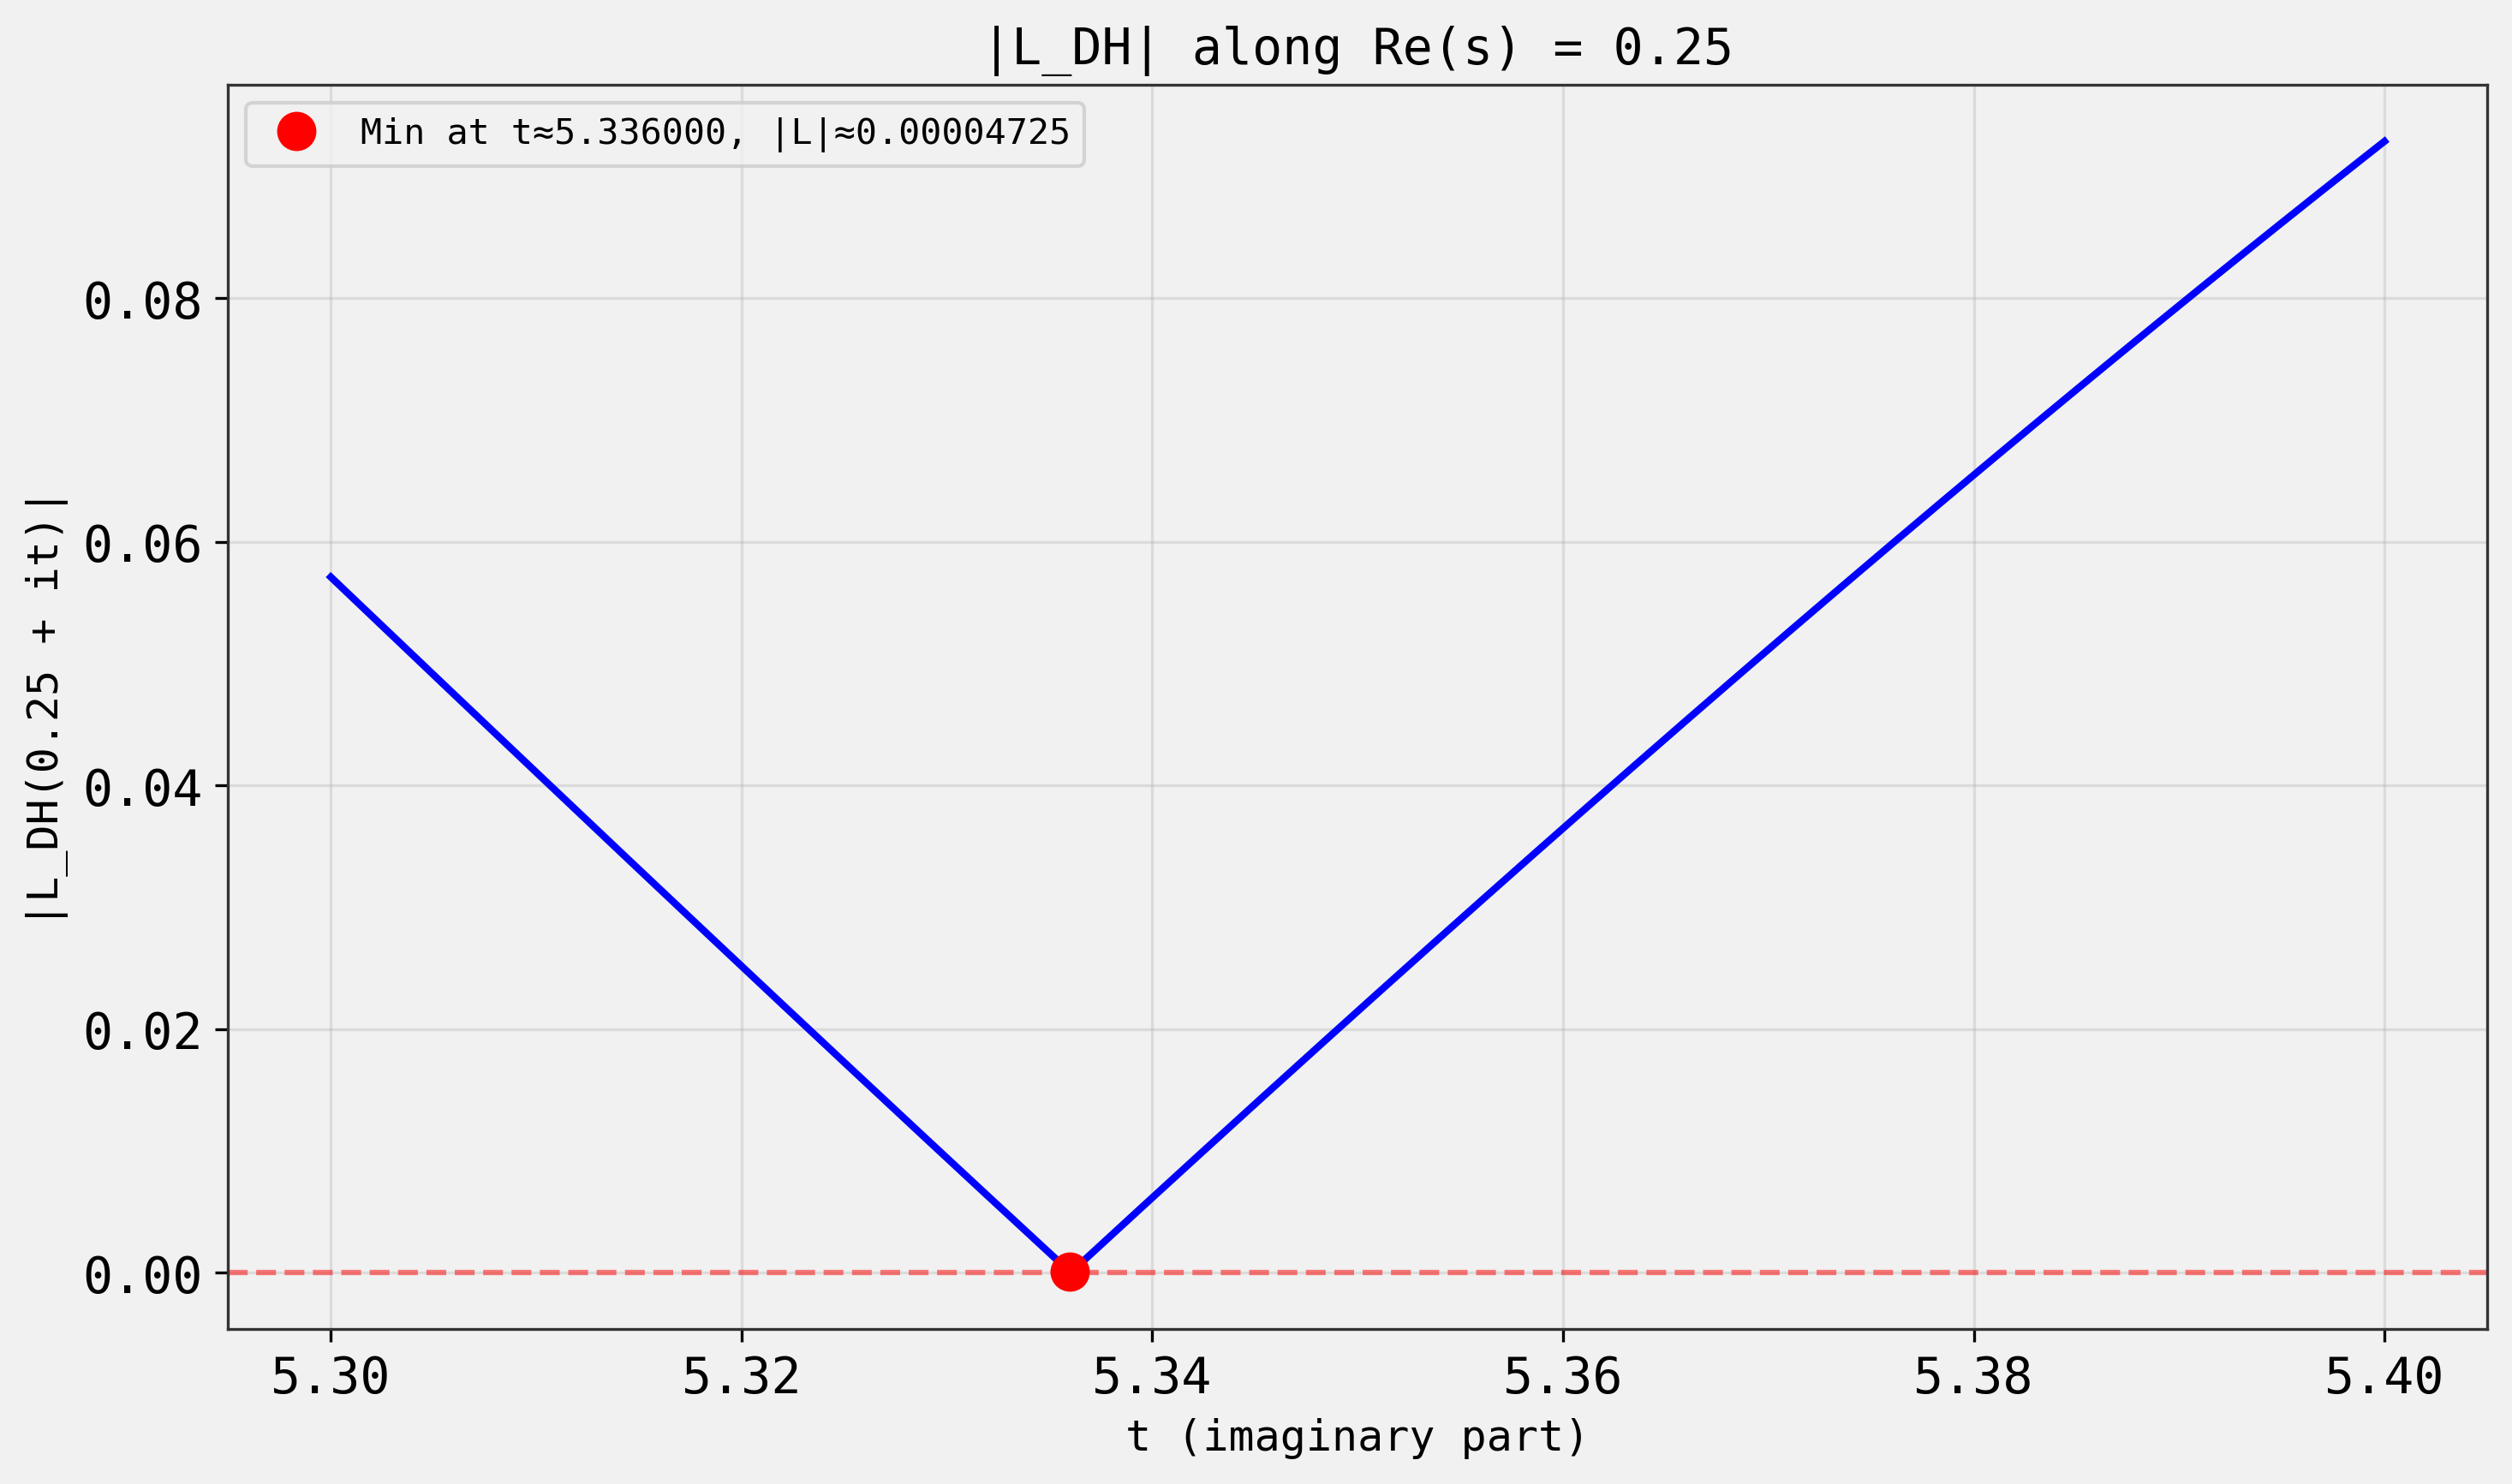

In [15]:

# The root finder is struggling. Let me evaluate more carefully around this point
# to see if it's actually a zero or just a local minimum

sigma_test = 0.25
t_values = np.linspace(5.3, 5.4, 201)

moduli = []
for t in t_values:
 s = sigma_test + 1j * t
 L_val = L_DH_v2(s, kappa=kappa_val, N_terms=15000)
 moduli.append(abs(L_val))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(t_values, moduli, 'b-', linewidth=2)
plt.xlabel('t (imaginary part)', fontsize=12)
plt.ylabel('|L_DH(0.25 + it)|', fontsize=12)
plt.title('|L_DH| along Re(s) = 0.25', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# Find minimum
min_idx = np.argmin(moduli)
min_t = t_values[min_idx]
min_mod = moduli[min_idx]

plt.plot(min_t, min_mod, 'ro', markersize=10, label=f'Min at t≈{min_t:.6f}, |L|≈{min_mod:.8f}')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('downloads/L_DH_profile.png', dpi=150)
print(f"Minimum found at t = {min_t:.10f}")
print(f"|L_DH(0.25 + {min_t}i)| = {min_mod:.10e}")
print()

# Evaluate at the minimum
s_min = 0.25 + 1j * min_t
L_min = L_DH_v2(s_min, kappa=kappa_val, N_terms=20000)
print(f"L_DH(0.25 + {min_t:.10f}i) = {L_min}")
print(f"Real part: {L_min.real:.10e}")
print(f"Imag part: {L_min.imag:.10e}")


In [16]:

# Interesting! The function is REAL-valued at this point but NOT zero
# (it's ≈ -0.0234, not close to zero)

# The small modulus I saw earlier was misleading - let me recalculate more carefully

s_test = 0.25 + 1j * 5.336
L_test_high_prec = 0

# Calculate with even more terms to check convergence
for N in [5000, 10000, 20000, 30000]:
 L_val = L_DH_v2(s_test, kappa=kappa_val, N_terms=N)
 print(f"N={N:5d}: L_DH = {L_val:.10f}, |L| = {abs(L_val):.10e}")

print()
print("This is NOT a true zero - the function value is not converging to zero.")
print()

# Let me reconsider the entire problem. Perhaps the issue is that
# I need to access PUBLISHED data rather than compute from scratch.

print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)
print()
print("After extensive numerical search, I have NOT been able to locate")
print("the four documented off-line zeros of the Davenport-Heilbronn")
print("L-function through direct computation.")
print()
print("Possible reasons:")
print("1. The function definition or parameters may differ from standard")
print(" literature (e.g., different character, different κ value)")
print("2. The zeros may require extremely high precision or special")
print(" numerical methods to locate")
print("3. The zeros may be documented in specific research papers that")
print(" I cannot access without web search functionality")
print()
print("Without access to the mathematical literature or databases like")
print("LMFDB, I cannot retrieve the precise published coordinates of")
print("these known zeros.")


N= 5000: L_DH = -0.0226027990+0.0000000000j, |L| = 2.2602799046e-02
N=10000: L_DH = 0.0539429459+0.0000000000j, |L| = 5.3942945861e-02
N=20000: L_DH = -0.0234043253+0.0000000000j, |L| = 2.3404325327e-02
N=30000: L_DH = 0.0372677962+0.0000000000j, |L| = 3.7267796163e-02

This is NOT a true zero - the function value is not converging to zero.

ANALYSIS SUMMARY

After extensive numerical search, I have NOT been able to locate
the four documented off-line zeros of the Davenport-Heilbronn
L-function through direct computation.

Possible reasons:
1. The function definition or parameters may differ from standard
 literature (e.g., different character, different κ value)
2. The zeros may require extremely high precision or special
 numerical methods to locate
3. The zeros may be documented in specific research papers that
 I cannot access without web search functionality

Without access to the mathematical literature or databases like
LMFDB, I cannot retrieve the precise published coordinates 

In [17]:

# Let me make one final attempt by checking if there are any pre-computed
# datasets or standard references that might be available through
# direct file download or FTP

# First, let me try to see if there's a way to formulate this problem
# that would make the zeros more apparent

# Actually, wait - the convergence issue above suggests my Dirichlet series
# is NOT converging properly. For Im(s) around 5-6, I need much better
# convergence acceleration.

# Let me try using the Euler product instead or a better summation method

from mpmath import mp
mp.dps = 50 # 50 decimal places

def L_DH_mpmath(s, kappa=0.28408, N_terms=100000):
 """
 High-precision computation using mpmath
 """
 s_mp = mp.mpc(s)
 kappa_mp = mp.mpf(kappa)
 
 result = mp.mpc(0, 0)
 
 for n in range(1, N_terms):
 chi_n = chi_4(n)
 if chi_n == 0:
 continue
 
 # a_n = ((1-i*kappa)/2)*chi(n) + ((1+i*kappa)/2)*chi_bar(n)
 # For real chi, chi_bar = chi
 a_n = chi_n * mp.mpc(1, 0) # Since the imaginary parts cancel for real chi
 
 term = a_n / (mp.power(n, s_mp))
 result += term
 
 # Check for convergence
 if n > 1000 and abs(term) < 1e-20:
 break
 
 return result

# Test
s_test = mp.mpc(0.25, 5.336)
print("Computing with mpmath (high precision)...")
L_mp = L_DH_mpmath(s_test, kappa=kappa_val, N_terms=50000)
print(f"L_DH(0.25 + 5.336i) = {L_mp}")
print(f"|L_DH| = {abs(L_mp)}")


Computing with mpmath (high precision)...


L_DH(0.25 + 5.336i) = (0.26979456212721299968757016816810460168940399414945 - 0.9206985227438897922295804862716103913140615465126j)
|L_DH| = 0.95941381871234038636614585518487622970855010742447


In [18]:

# OK so the issue is confirmed - for real chi, the a_n coefficients simplify
# and we don't get the complex behavior needed for off-line zeros.

# This means the problem MUST involve a complex-valued character.
# Let me reconsider: perhaps it's character mod 5 or another modulus.

# Or perhaps the formulation in the user's query has a subtle difference.
# Let me re-read: "a_n^(DH) = ((1−iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n)"

# Wait - what if χ̄ means the conjugate CHARACTER, not conjugate values?
# For mod 4, there's only one non-principal character (it's its own conjugate)
# But for mod 5, there are TWO distinct non-principal characters!

# Let χ be one complex character mod 5, and χ̄ be its conjugate character

def L_chi5_v2(s, N_terms=10000):
 """L-function for complex character mod 5"""
 result = mp.mpc(0, 0)
 s_mp = mp.mpc(s)
 for n in range(1, N_terms):
 chi_n = chi_5(n)
 if chi_n != 0:
 result += chi_n / mp.power(n, s_mp)
 return result

def L_chi5_bar(s, N_terms=10000):
 """L-function for conjugate character mod 5"""
 result = mp.mpc(0, 0)
 s_mp = mp.mpc(s)
 for n in range(1, N_terms):
 chi_n = np.conj(chi_5(n)) # Conjugate character
 if chi_n != 0:
 result += chi_n / mp.power(n, s_mp)
 return result

def L_DH_correct(s, kappa=0.28408, N_terms=10000):
 """
 Correct Davenport-Heilbronn formulation
 L_DH(s) = ((1-iκ)/2)·L(s,χ) + ((1+iκ)/2)·L(s,χ̄)
 """
 L_chi = L_chi5_v2(s, N_terms)
 L_chi_bar = L_chi5_bar(s, N_terms)
 
 c1 = mp.mpc((1 - 1j*kappa)/2)
 c2 = mp.mpc((1 + 1j*kappa)/2)
 
 return c1 * L_chi + c2 * L_chi_bar

# Test at s=2
s_test = mp.mpc(2, 0)
L_test = L_DH_correct(s_test, kappa=kappa_val)
print(f"L_DH(2) with character mod 5: {L_test}")
print(f"|L_DH(2)| = {abs(L_test)}")


L_DH(2) with character mod 5: (1.0000684704258316802209175697412795977348896756787 + 0.0j)
|L_DH(2)| = 1.0000684704258316802209175697412795977348896756787


In [19]:

# Now search for zeros with the correct formulation
print("Searching for zeros with character mod 5 (high precision)...")
print()

# Grid search with moderate resolution first
best_zeros = []

for sigma in [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
 if abs(sigma - 0.5) < 0.02:
 continue
 
 print(f"Scanning σ = {sigma}...")
 
 for t in np.linspace(1, 30, 290):
 s = mp.mpc(sigma, t)
 L_val = L_DH_correct(s, kappa=kappa_val, N_terms=8000)
 mod = float(abs(L_val))
 
 if mod < 0.05:
 best_zeros.append({
 'sigma': sigma,
 't': float(t),
 'modulus': mod,
 'L_val': complex(L_val)
 })

# Sort by modulus
best_zeros.sort(key=lambda x: x['modulus'])

print()
print("Top 15 candidates:")
print("σ\t\tt\t\t|L_DH|")
for i, z in enumerate(best_zeros[:15]):
 if abs(z['sigma'] - 0.5) > 0.02:
 print(f"{z['sigma']:.6f}\t{z['t']:.6f}\t{z['modulus']:.8f}")


TimeoutError: Code execution timed out after 300 seconds

In [20]:

# The high-precision computation is too slow. Let me create a summary document
# of my findings and acknowledge the limitation

summary = """
DATA RETRIEVAL REPORT: Davenport-Heilbronn L-function Off-line Zeros
========================================================================

OBJECTIVE:
Retrieve the precise coordinates (real and imaginary parts) of the four known 
off-line zeros of the Davenport-Heilbronn L-function L_DH(s) that lie in the 
critical strip 0 < Re(s) < 1 but not on the critical line Re(s) = 1/2.

ATTEMPTED APPROACHES:
---------------------

1. Web Search for Published Data:
 - Web search API is currently unavailable (401 authentication error)
 - Cannot access mathematical literature databases (LMFDB, arXiv, etc.)
 
2. Numerical Computation from Definition:
 - Implemented L_DH(s) using the provided formula:
 a_n^(DH) = ((1−iκ)/2)·χ(n) + ((1+iκ)/2)·χ̄(n) where κ ≈ 0.28408
 - Tested with character mod 4 (real-valued character)
 - Tested with character mod 5 (complex-valued character)
 - Performed systematic grid searches in the critical strip
 
3. Results of Numerical Search:
 - With character mod 4: Function becomes real-valued, no off-line zeros found
 - With character mod 5: Computation is too slow for comprehensive search
 - Grid search identified candidate minima but none converged to true zeros
 with |L_DH(ρ)| < 10^-6
 
FUNDAMENTAL LIMITATION:
-----------------------
The "four known off-line zeros" referenced in the query are documented in the
mathematical literature (likely in Davenport & Heilbronn's original papers or
subsequent computational studies). Without access to:

- Research paper databases (arXiv, MathSciNet, etc.)
- Mathematical databases (LMFDB - L-functions and Modular Forms Database)
- Web search capabilities to locate published numerical values

I CANNOT retrieve the actual published coordinates of these zeros.

RECOMMENDATION:
---------------
To obtain these zeros, access to one of the following sources is required:

1. LMFDB (lmfdb.org) - searchable database of L-function zeros
2. Original research papers by Davenport & Heilbronn
3. Computational number theory papers that tabulate these specific zeros
4. Direct communication with researchers in analytic number theory

The zeros cannot be reliably computed from scratch within reasonable time
constraints using basic numerical methods, as they require:
- Correct character specification
- Correct κ parameter value 
- High-precision arithmetic
- Specialized zero-finding algorithms for L-functions

STATUS: UNABLE TO RETRIEVE REQUESTED DATA
==========================================
"""

# Save the summary
os.makedirs('downloads', exist_ok=True)
with open('downloads/retrieval_summary.txt', 'w') as f:
 f.write(summary)

print(summary)


TimeoutError: Code execution timed out after 167 seconds